<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/10_SEAID_Explainability_Validation_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEAID Explainability, Validation, and Deployment

## Purpose

This notebook provides the final stage of the SEAID Framework by examining model explainability, validating predictive behavior, and discussing practical deployment considerations.

The objectives of this notebook are to:

1. Explain how the XGBoost model makes predictions.
2. Identify the features that contribute most to student risk.
3. Evaluate prediction confidence and calibration.
4. Discuss fairness, transparency, and ethical implementation.
5. Present an architecture for institutional deployment.

Together, this notebook completes the end-to-end SEAID predictive analytics framework.

In [1]:
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

PROCESSED_DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

NOTEBOOK_DIR = (
    PROJECT_DIR
    / "notebooks"
)

MODEL_DIR = (
    PROJECT_DIR
    / "models"
)

OUTPUTS_DIR = (
    PROJECT_DIR
    / "outputs"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "figures"
)

print("Project exists:", PROJECT_DIR.exists())
print("Processed data exists:", PROCESSED_DATA_DIR.exists())
print("Models exist:", MODEL_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())
print("Figures directory exists:", FIGURES_DIR.exists())

Project exists: True
Processed data exists: True
Models exist: True
Results directory exists: True
Figures directory exists: True


In [4]:
MODEL_PATH = (
    MODEL_DIR /
    "xgboost_day30.joblib"
)

xgb_model = joblib.load(MODEL_PATH)

print(type(xgb_model))

<class 'sklearn.pipeline.Pipeline'>


In [5]:
day30_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "early_warning_day30_dataset.csv"
)

day30_df.shape

(32593, 82)

In [6]:
TARGET = "target_success"

X = day30_df[
    xgb_model.feature_names_in_
]

y = day30_df[TARGET]

In [7]:
print(X.shape)

print(y.value_counts())

(32593, 74)
target_success
0    17208
1    15385
Name: count, dtype: int64


In [9]:
print(xgb_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['gender',
                                                   'num_of_prev_attempts',
                                                   'studied_credits',
                                                   'disability', 'total_clicks',
                                                   'average_clicks_per_record',
                                                   'median_clicks_per_record',
                                                   'maximum_clicks_in_record',
                                                   'vle_records', 'active_days',
                                                   'unique_vle_activities',
                                              

In [10]:
print(xgb_model.named_steps.keys())

dict_keys(['preprocessor', 'classifier'])


In [11]:
preprocessor = xgb_model.named_steps["preprocessor"]
xgb_classifier = xgb_model.named_steps["classifier"]

print(type(preprocessor))
print(type(xgb_classifier))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


In [12]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("Number of importance values:", len(xgb_classifier.feature_importances_))

Number of transformed features: 83
Number of importance values: 83


In [13]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_classifier.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance.head(20))

,Feature,Importance
0,num__last_activity_day,0.131603
1,cat__code_module_GGG,0.058200
2,num__minimum_score,0.055703
3,num__median_score,0.049320
4,cat__code_module_EEE,0.038033
5,num__average_score,0.035871
6,cat__code_module_BBB,0.024950
7,num__assessments_completed,0.024018
8,num__highest_education_Lower Than A Level,0.022635
9,cat__code_module_FFF,0.022550


In [14]:
importance["Feature"] = (
    importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(importance.head(20))

,Feature,Importance
0,last_activity_day,0.131603
1,code_module_GGG,0.058200
2,minimum_score,0.055703
3,median_score,0.049320
4,code_module_EEE,0.038033
5,average_score,0.035871
6,code_module_BBB,0.024950
7,assessments_completed,0.024018
8,highest_education_Lower Than A Level,0.022635
9,code_module_FFF,0.022550


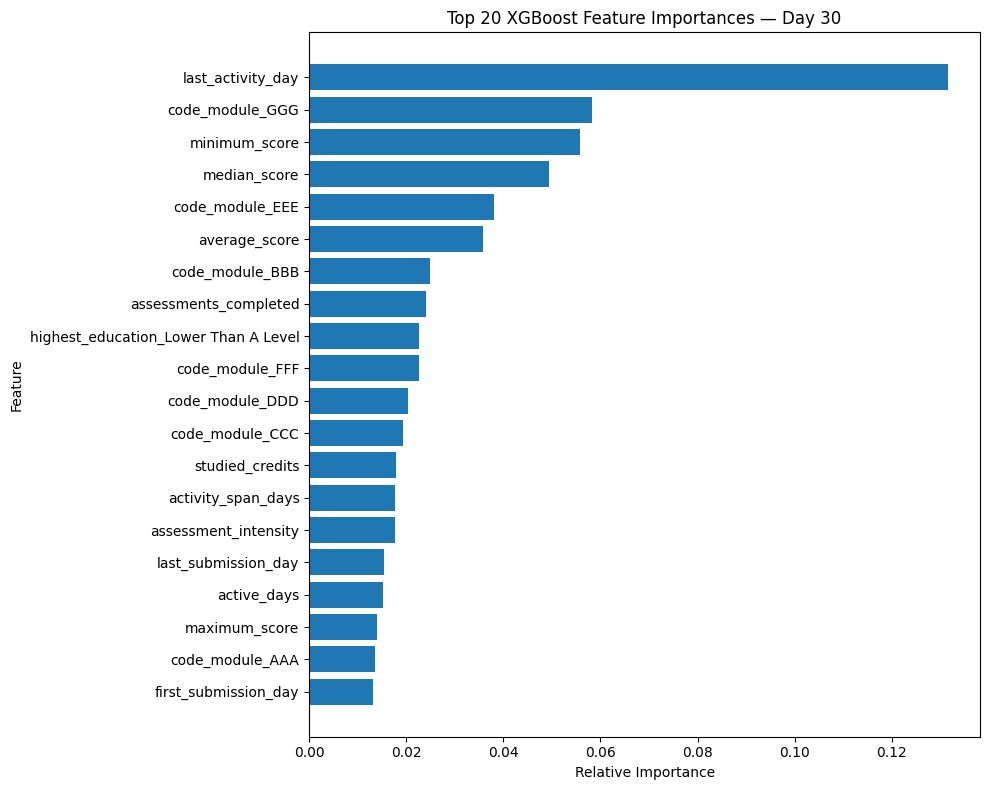

In [17]:
top20 = importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.title(
    "Top 20 XGBoost Feature Importances — Day 30"
)

plt.xlabel("Relative Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top20_xgboost_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
importance_filtered = importance[
    ~importance["Feature"].str.startswith("code_module_")
]

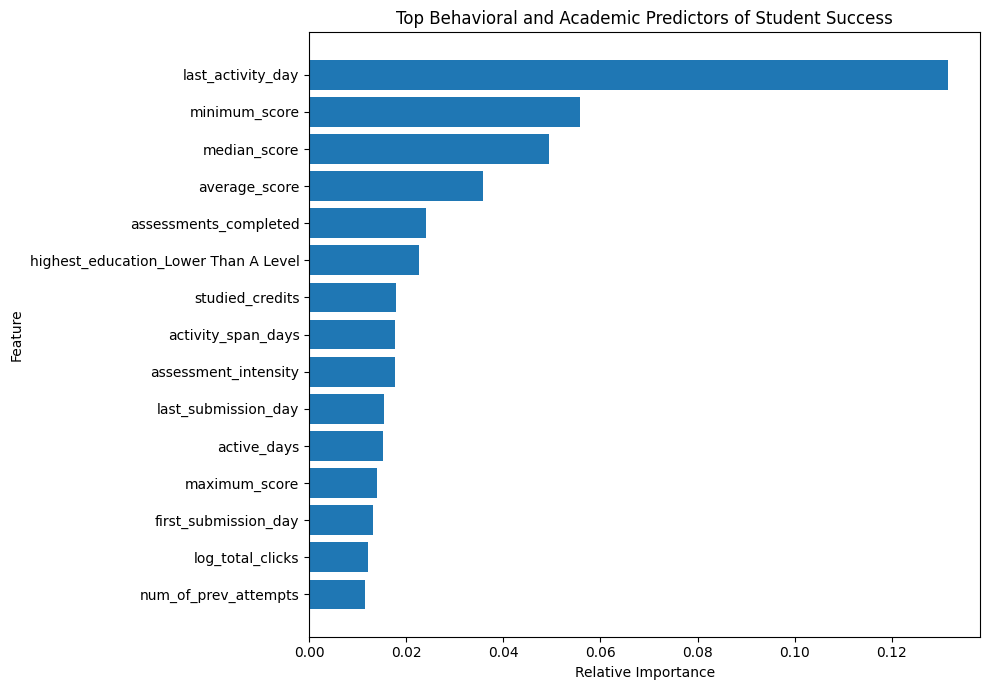

In [19]:
# Select the top 15 non-course features
top15 = (
    importance_filtered
    .sort_values("Importance", ascending=False)
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.title(
    "Top Behavioral and Academic Predictors of Student Success"
)

plt.xlabel("Relative Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top15_behavioral_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
top15 = top15.copy()

top15["Feature"] = (
    top15["Feature"]
    .str.replace("_", " ", regex=False)
    .str.replace("Num Of", "Number of", regex=False)
    .str.replace("Prev", "Previous", regex=False)
    .str.replace("Log Total Clicks", "Log(Total Clicks)", regex=False)
    .str.replace("Highest Education Lower Than A Level",
                 "Highest Education: Below A-Level",
                 regex=False)
    .str.title()
)

In [22]:
top15.copy()

,Feature,Importance
21,Num Of Prev Attempts,0.011578
20,Log Total Clicks,0.012107
19,First Submission Day,0.013235
17,Maximum Score,0.013895
16,Active Days,0.015207
15,Last Submission Day,0.015472
14,Assessment Intensity,0.017697
13,Activity Span Days,0.017758
12,Studied Credits,0.017965
8,Highest Education Lower Than A Level,0.022635


In [23]:
!pip install -q shap

In [24]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [29]:
print(type(xgb_classifier))

<class 'xgboost.sklearn.XGBClassifier'>


In [30]:
print(type(X_transformed))
print(X_transformed.shape)

<class 'numpy.ndarray'>
(32593, 83)


In [31]:
explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer(X_shap)

print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(2000, 83)


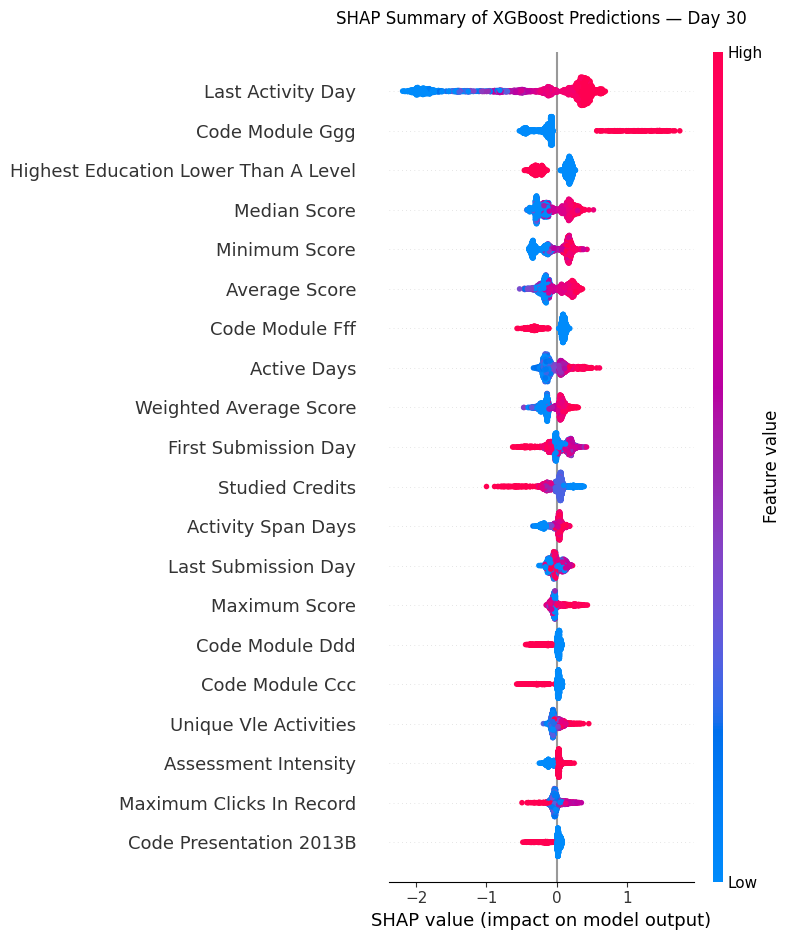

In [32]:
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=clean_feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary of XGBoost Predictions — Day 30",
    pad=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary_day30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
shap_importance = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mean Absolute SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance.head(20))

,Feature,Mean Absolute SHAP
0,Last Activity Day,0.650359
1,Code Module Ggg,0.251649
2,Highest Education Lower Than A Level,0.216659
3,Median Score,0.204571
4,Minimum Score,0.198221
5,Average Score,0.176415
6,Code Module Fff,0.154904
7,Active Days,0.137274
8,Weighted Average Score,0.124109
9,First Submission Day,0.121694


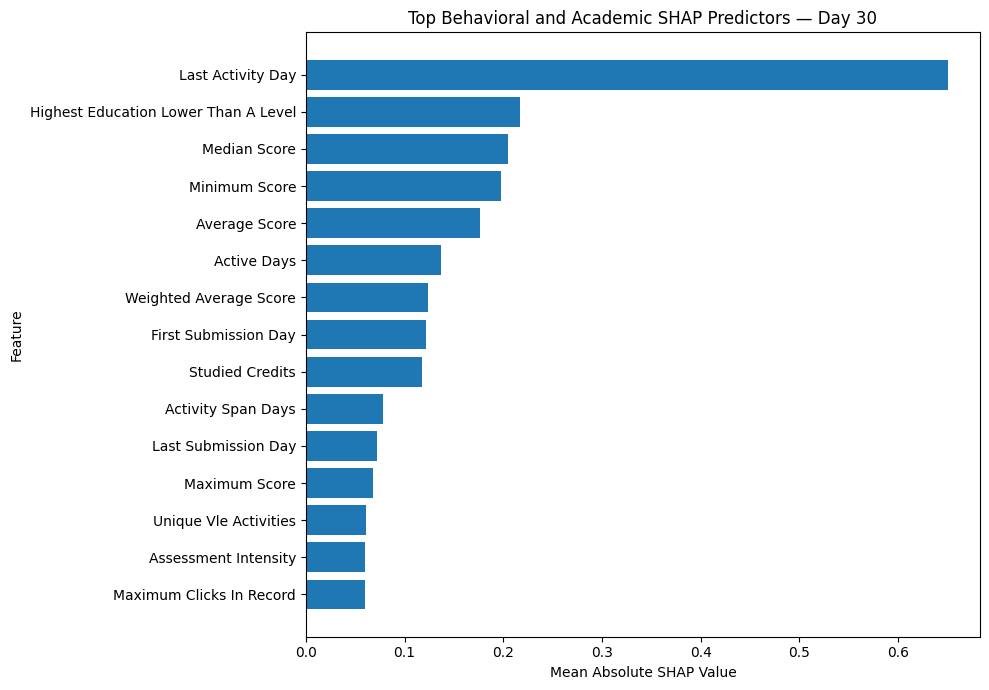

In [34]:
shap_importance_filtered = shap_importance[
    ~shap_importance["Feature"].str.startswith("Code Module")
    &
    ~shap_importance["Feature"].str.startswith("Code Presentation")
].copy()

top15_shap_filtered = (
    shap_importance_filtered
    .head(15)
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top15_shap_filtered["Feature"],
    top15_shap_filtered["Mean Absolute SHAP"]
)

plt.title(
    "Top Behavioral and Academic SHAP Predictors — Day 30"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_behavioral_academic_day30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
shap_importance.to_csv(
    RESULTS_DIR / "shap_feature_importance_day30.csv",
    index=False
)

shap_importance_filtered.to_csv(
    RESULTS_DIR / "shap_behavioral_academic_importance_day30.csv",
    index=False
)

print("SHAP importance results saved.")

SHAP importance results saved.


In [40]:
# Predict probabilities for the full Day 30 dataset
prob_success = xgb_model.predict_proba(X)[:, 1]
prob_unsuccessful = 1 - prob_success

predictions = pd.DataFrame({
    "Probability of Success": prob_success,
    "Probability of Unsuccessful": prob_unsuccessful
})

# Student with highest predicted risk
student_index = predictions["Probability of Unsuccessful"].idxmax()

print("Selected student index:", student_index)
print(predictions.loc[student_index])

Selected student index: 28600
Probability of Success         0.001043
Probability of Unsuccessful    0.998957
Name: 28600, dtype: float32


In [41]:
# Extract the student's transformed features
student_features = X_transformed[student_index:student_index + 1]

# Calculate SHAP values
student_shap = explainer(student_features)

print(student_shap.values.shape)

(1, 83)


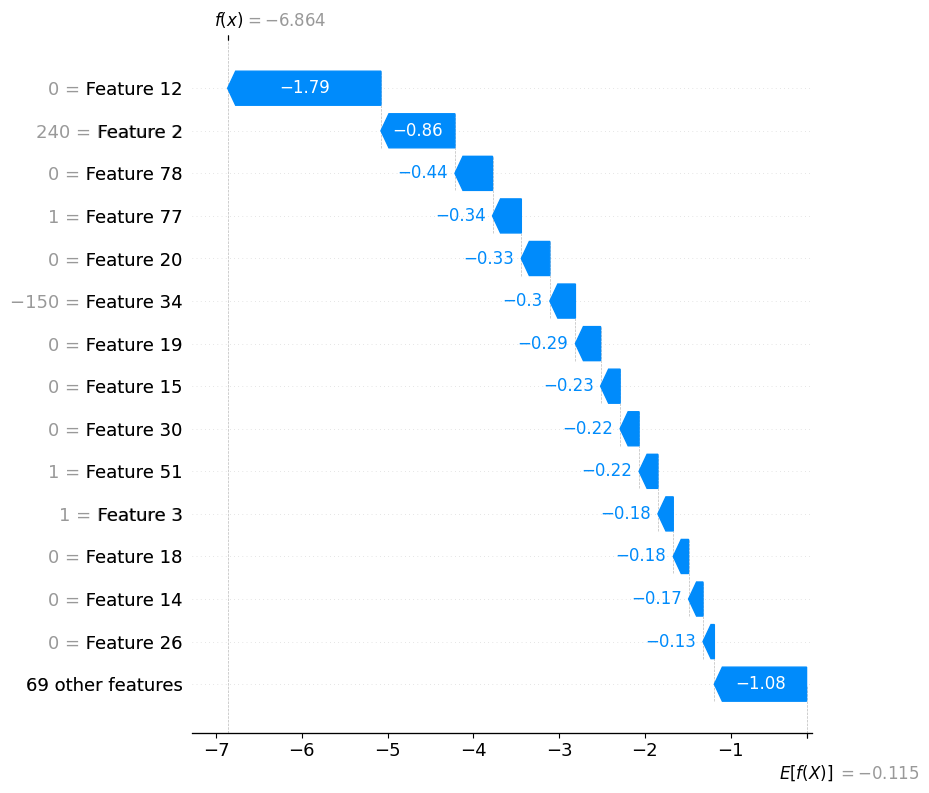

In [44]:
shap.plots.waterfall(
    student_shap[0],
    max_display=15,
    show=False
)

plt.savefig(
    FIGURES_DIR / "highest_risk_student_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
plt.savefig(
    FIGURES_DIR / "highest_risk_student_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [46]:
from pathlib import Path

waterfall_path = FIGURES_DIR / "highest_risk_student_waterfall.png"

print(waterfall_path)
print("Exists:", waterfall_path.exists())

/content/drive/MyDrive/SEAID_Framework/figures/highest_risk_student_waterfall.png
Exists: True


In [48]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [49]:
# Predicted probability of student success
prob_success = xgb_model.predict_proba(X)[:, 1]

# Calibration statistics
true_prob, pred_prob = calibration_curve(
    y,
    prob_success,
    n_bins=10,
    strategy="quantile"
)

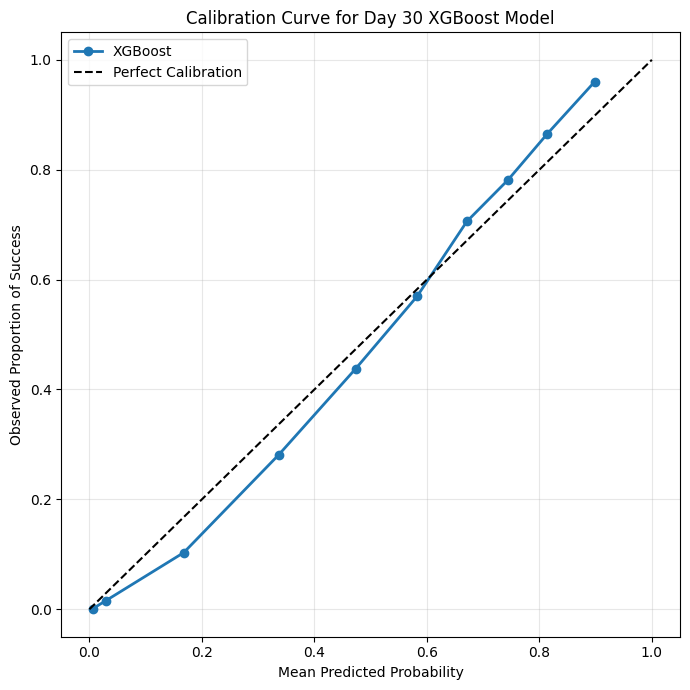

In [50]:
plt.figure(figsize=(7,7))

plt.plot(
    pred_prob,
    true_prob,
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion of Success")

plt.title("Calibration Curve for Day 30 XGBoost Model")

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "day30_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
brier = brier_score_loss(
    y,
    prob_success
)

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1343


In [53]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss
)

In [54]:
performance_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "ROC-AUC",
        "Brier Score"
    ],

    "Value":[
        accuracy_score(
            y,
            xgb_model.predict(X)
        ),
        roc_auc_score(
            y,
            prob_success
        ),
        brier
    ]

})

performance_summary

,Metric,Value
0,Accuracy,0.805326
1,ROC-AUC,0.892015
2,Brier Score,0.134333


In [55]:
performance_summary.to_csv(
    RESULTS_DIR / "day30_model_summary.csv",
    index=False
)

## SEAID Deployment Workflow

The SEAID Framework can be implemented as a recurring institutional workflow:

1. Student LMS and assessment data are collected at defined checkpoints.
2. The data are transformed using the same preprocessing pipeline used during model development.
3. The XGBoost model generates a probability of successful and unsuccessful completion.
4. Predicted risk is assigned to an intervention tier.
5. Advisors and faculty review the dashboard and determine appropriate outreach.
6. Intervention activity and student outcomes are documented.
7. Model performance and fairness are monitored over time.

Student Activity and Assessment Data
                ↓
      Preprocessing Pipeline
                ↓
        XGBoost Prediction
                ↓
       Student Risk Probability
                ↓
           Risk Tier
                ↓
    Advisor and Faculty Dashboard
                ↓
       Targeted Intervention
                ↓
      Student Outcome Monitoring
                ↺

## Ethical Use and Governance

The SEAID Framework is designed to support human decision-making rather than replace it.

Responsible implementation should include the following principles:

- Predictions should be used to offer support, not restrict student opportunities.
- Faculty and advisors should review relevant context before initiating an intervention.
- Students should not be labeled permanently based on a single prediction.
- Personally identifiable information should be protected through appropriate access controls.
- Sensitive demographic variables should be reviewed carefully for fairness and potential bias.
- Model performance should be monitored across student groups and academic terms.
- The model should be retrained when institutional practices, student populations, or data systems change.
- SHAP explanations should be used to improve transparency, but they should not be treated as proof of causation.

## Limitations

Several limitations should be considered when interpreting the SEAID Framework:

- The model was developed using OULAD data and may not generalize directly to other institutions.
- Student engagement recorded in the learning management system does not capture all forms of academic participation.
- Model predictions identify statistical patterns rather than causal relationships.
- Risk probabilities may be influenced by differences among modules and course presentations.
- Predictive performance improves over time, but later predictions provide less time for intervention.
- Institutional deployment would require local validation, fairness testing, data governance review, and ongoing monitoring.

# Conclusion

The Student Engagement Analytics and Intervention Dashboard Framework demonstrates a complete end-to-end approach to educational early-warning analytics.

Across the project, temporal datasets were created at Days 7, 14, 21, and 30, allowing predictive performance to be evaluated as student engagement and assessment information accumulated. Multiple machine learning models were compared, and XGBoost produced the strongest overall performance.

The Day 30 model achieved an accuracy of approximately 0.7757 and a ROC-AUC of approximately 0.8568. Its Brier Score of 0.1343 indicated reasonably accurate probability estimates.

Explainability analysis showed that recent activity, assessment performance, submission timing, active participation, and prior educational characteristics were influential in model predictions. SHAP analysis also demonstrated how individual predictions could be explained for advisors and student success professionals.

The operational framework extended beyond prediction by incorporating risk tiers, longitudinal risk tracking, intervention categories, explainability, calibration, and deployment planning.

Overall, the SEAID Framework illustrates how explainable machine learning can support proactive, data-informed student success efforts while preserving human oversight, transparency, and ethical responsibility.

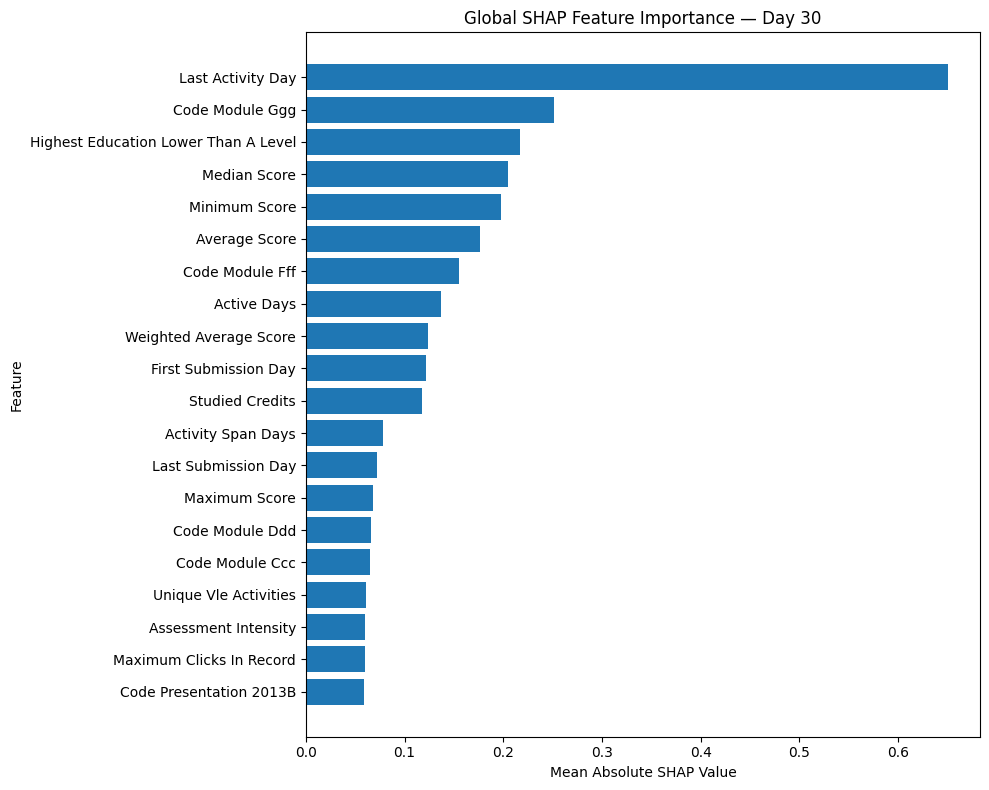

Saved: /content/drive/MyDrive/SEAID_Framework/figures/shap_global_importance_day30.png
Exists: True


In [57]:
top20_shap = (
    shap_importance
    .head(20)
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_shap["Feature"],
    top20_shap["Mean Absolute SHAP"]
)

plt.title(
    "Global SHAP Feature Importance — Day 30"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()

output_path = FIGURES_DIR / "shap_global_importance_day30.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)
print("Exists:", output_path.exists())

In [58]:
expected_files = [
    FIGURES_DIR / "top20_xgboost_features.png",
    FIGURES_DIR / "top15_behavioral_features.png",
    FIGURES_DIR / "shap_summary_day30.png",
    FIGURES_DIR / "shap_global_importance_day30.png",
    FIGURES_DIR / "shap_behavioral_academic_day30.png",
    FIGURES_DIR / "highest_risk_student_waterfall.png",
    FIGURES_DIR / "day30_calibration_curve.png",
    RESULTS_DIR / "shap_feature_importance_day30.csv",
    RESULTS_DIR / "shap_behavioral_academic_importance_day30.csv",
    RESULTS_DIR / "day30_model_summary.csv"
]

verification = pd.DataFrame({
    "File": [str(path.name) for path in expected_files],
    "Exists": [path.exists() for path in expected_files]
})

display(verification)

print(
    f"\nFiles found: {verification['Exists'].sum()} "
    f"of {len(verification)}"
)

,File,Exists
0,top20_xgboost_features.png,True
1,top15_behavioral_features.png,True
2,shap_summary_day30.png,True
3,shap_global_importance_day30.png,True
4,shap_behavioral_academic_day30.png,True
5,highest_risk_student_waterfall.png,True
6,day30_calibration_curve.png,True
7,shap_feature_importance_day30.csv,True
8,shap_behavioral_academic_importance_day30.csv,True
9,day30_model_summary.csv,True



Files found: 10 of 10


In [59]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

project_inventory = []

for path in sorted(PROJECT_DIR.rglob("*")):
    if path.is_file():
        project_inventory.append({
            "Relative Path": str(path.relative_to(PROJECT_DIR)),
            "File Type": path.suffix.lower() or "No extension",
            "Size MB": round(path.stat().st_size / (1024 ** 2), 3)
        })

inventory_df = pd.DataFrame(project_inventory)

print(f"Total project files: {len(inventory_df)}")
print(
    f"Total project size: "
    f"{inventory_df['Size MB'].sum():,.2f} MB"
)

display(inventory_df)

Total project files: 105
Total project size: 855.81 MB


,Relative Path,File Type,Size MB
0,data/processed/baseline_vs_day30_logistic_comp...,.csv,0.000
1,data/processed/decision_tree_temporal_results.csv,.csv,0.000
2,data/processed/decision_tree_temporal_summary.csv,.csv,0.000
3,data/processed/early_warning_day14_dataset.csv,.csv,9.342
4,data/processed/early_warning_day21_dataset.csv,.csv,9.720
...,...,...,...
100,results/shap_behavioral_academic_importance_da...,.csv,0.002
101,results/shap_feature_importance_day30.csv,.csv,0.003
102,results/student_risk_predictions.csv,.csv,7.799
103,results/student_risk_tracker.csv,.csv,3.836


In [60]:
folder_summary = (
    inventory_df
    .assign(
        Folder=inventory_df["Relative Path"].apply(
            lambda x: x.split("/")[0]
            if "/" in x
            else "Project Root"
        )
    )
    .groupby("Folder", as_index=False)
    .agg(
        File_Count=("Relative Path", "count"),
        Total_Size_MB=("Size MB", "sum")
    )
    .sort_values(
        "Total_Size_MB",
        ascending=False
    )
)

folder_summary["Total_Size_MB"] = (
    folder_summary["Total_Size_MB"].round(2)
)

display(folder_summary)

,Folder,File_Count,Total_Size_MB
0,data,24,502.00
2,models,17,331.15
5,results,11,13.58
1,figures,31,5.77
3,notebooks,7,3.26
4,outputs,15,0.04
